# Parte 3 — Word2Vec e Similaridade Semântica entre Letras de Músicas Brasileiras

Este notebook corresponde à terceira parte do trabalho de NLP. O objetivo é treinar um modelo **Word2Vec** em cima das letras pré-processadas e analisar a similaridade semântica entre músicas/documentos.

## Objetivos desta etapa

1. Carregar o dataset de letras limpas.
2. Preparar os documentos tokenizados.
3. Treinar um modelo Word2Vec.
4. Gerar vetores de documentos pela média dos vetores das palavras.
5. Calcular similaridade por cosseno entre músicas.
6. Buscar músicas similares por consulta textual.
7. Buscar músicas similares a uma música específica.
8. Visualizar similaridades com heatmap e PCA.
9. Opcionalmente, agrupar documentos com KMeans.

## 1. Instalação e importação das bibliotecas

> Em ambientes como Google Colab, a instalação pode ser necessária. Em Jupyter local, execute apenas se a biblioteca não estiver instalada.

In [1]:
!pip install --upgrade gensim nltk scikit-learn plotly --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 37.4 MB/s eta 0:00:00


In [2]:
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize

from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import plotly.express as px

warnings.filterwarnings("ignore")
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

True

## 2. Carregamento do dataset

Este notebook assume que já existe um arquivo CSV gerado nas etapas anteriores, contendo ao menos:

- `lyrics_clean`: letra limpa
- `song_title`: título da música
- `artist`: artista
- `genre`: gênero musical

Se o seu arquivo tiver outro nome, altere a variável `DATA_PATH`.

In [4]:
DATA_PATH = "songs.csv"  # altere se necessário, ex.: "/content/songs.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Arquivo não encontrado: {DATA_PATH}. "
        "Envie o CSV para o ambiente ou altere DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print("Formato do dataset:", df.shape)
display(df.head())

Formato do dataset: (100, 10)


,genre,artist,artist_slug,artist_url,song_title,song_url,lyrics_raw,lyrics_clean,n_words,n_chars
0,mpb,Maria Bethânia,maria-bethania,https://www.letras.com.br/maria-bethania/,Iemanjá Rainha Do Mar,https://www.letras.com.br/maria-bethania/ieman...,Quanto nome tem a Rainha do Mar?\nQuanto nome ...,Quanto nome tem a Rainha do Mar?\nQuanto nome ...,163,852
1,mpb,Maria Bethânia,maria-bethania,https://www.letras.com.br/maria-bethania/,Samba Da Bênção,https://www.letras.com.br/maria-bethania/samba...,É melhor ser alegre que ser triste\nAlegria é ...,É melhor ser alegre que ser triste\nAlegria é ...,149,712
2,mpb,Fagner,fagner,https://www.letras.com.br/fagner/,Borbulhas de Amor,https://www.letras.com.br/fagner/borbulhas-de-...,Tenho um coração\nDividido entre a esperança e...,Tenho um coração\nDividido entre a esperança e...,229,1234
3,mpb,Fagner,fagner,https://www.letras.com.br/fagner/,Oração de São Francisco,https://www.letras.com.br/fagner/oracao-de-sao...,"Senhor, fazei-me instrumento de vossa paz\nOnd...","Senhor, fazei-me instrumento de vossa paz\nOnd...",109,584
4,mpb,Marcos Valle,marcos-valle,https://www.letras.com.br/marcos-valle/,Um Novo Tempo,https://www.letras.com.br/marcos-valle/um-novo...,Hoje é um novo dia\nDe um novo tempo que come...,Hoje é um novo dia\nDe um novo tempo que come...,63,297


In [5]:
required_columns = ["lyrics_clean", "song_title", "artist", "genre"]
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Colunas obrigatórias ausentes: {missing_columns}")

# Garante que letras vazias não quebrem o pipeline
df = df.dropna(subset=["lyrics_clean"]).reset_index(drop=True)
df["lyrics_clean"] = df["lyrics_clean"].astype(str)

print("Dataset após remover letras vazias:", df.shape)
print("Distribuição por gênero:")
display(df["genre"].value_counts())

Dataset após remover letras vazias: (100, 10)
Distribuição por gênero:


,count
genre,
mpb,20
rock,20
sertanejo,20
funk,20
rap,20


## 3. Preparação dos documentos

Aqui os documentos são tokenizados. Como as etapas anteriores já fizeram limpeza, remoção de stopwords, stemming/lemmatização etc., esta etapa apenas transforma cada letra em uma lista de tokens.

Se ainda aparecerem ruídos como `youtube`, números, `1x`, `êe`, `refr`, etc., volte à etapa de limpeza antes de treinar o Word2Vec.

In [6]:
def tokenize_document(text: str) -> list[str]:
    """Tokeniza uma letra já limpa."""
    tokens = word_tokenize(text.lower(), language="portuguese")
    tokens = [tok for tok in tokens if tok.strip()]
    return tokens

# Documento = uma música/documento textual
documentos = df["lyrics_clean"].tolist()
documentos_tokenizados = [tokenize_document(doc) for doc in documentos]

print("Quantidade de documentos:", len(documentos_tokenizados))
print("Exemplo de tokens do primeiro documento:")
print(documentos_tokenizados[0][:40])

Quantidade de documentos: 100
Exemplo de tokens do primeiro documento:
['quanto', 'nome', 'tem', 'a', 'rainha', 'do', 'mar', '?', 'quanto', 'nome', 'tem', 'a', 'rainha', 'do', 'mar', '?', 'dandalunda', ',', 'janaína', ',', 'marabô', ',', 'princesa', 'de', 'aiocá', ',', 'inaê', ',', 'sereia', ',', 'mucunã', ',', 'maria', ',', 'dona', 'iemanjá', '.', 'onde', 'ela', 'vive']


In [7]:
# Checagem rápida de vocabulário e tokens mais frequentes
all_tokens = [token for doc in documentos_tokenizados for token in doc]
token_freq = pd.Series(all_tokens).value_counts()

print("Quantidade total de tokens:", len(all_tokens))
print("Tamanho do vocabulário:", token_freq.shape[0])
display(token_freq.head(30).to_frame("freq"))

Quantidade total de tokens: 26413
Tamanho do vocabulário: 4384


,freq
",",1426
que,794
e,693
de,661
o,633
a,627
eu,568
é,511
não,444
um,297


## 4. Treinamento do modelo Word2Vec

O Word2Vec aprende representações vetoriais das palavras com base no contexto em que elas aparecem.

Parâmetros principais:

- `vector_size`: dimensão dos vetores
- `window`: tamanho da janela de contexto
- `min_count`: frequência mínima para manter uma palavra no vocabulário
- `sg=0`: CBOW
- `sg=1`: Skip-gram

Para um corpus pequeno, `min_count=1` evita perder vocabulário. Em corpora maiores, `min_count=2` ou `3` reduz ruído.

In [8]:
VECTOR_SIZE = 100
WINDOW_SIZE = 5
MIN_COUNT = 1
WORKERS = 4
SG = 0  # 0 = CBOW, 1 = Skip-gram
SEED = 42

model_w2v = Word2Vec(
    sentences=documentos_tokenizados,
    vector_size=VECTOR_SIZE,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    workers=WORKERS,
    sg=SG,
    seed=SEED
)

print(f"Modelo treinado com vocabulário de {len(model_w2v.wv.index_to_key)} palavras.")
print("Exemplo de palavras no vocabulário:")
print(model_w2v.wv.index_to_key[:30])

Modelo treinado com vocabulário de 4384 palavras.
Exemplo de palavras no vocabulário:
[',', 'que', 'e', 'de', 'o', 'a', 'eu', 'é', 'não', 'um', 'pra', 'se', 'me', 'você', '!', 'do', 'na', 'no', 'meu', '?', 'por', 'mais', 'te', 'com', 'já', 'só', 'da', 'uma', 'amor', 'tem']


## 5. Similaridade entre palavras

Antes de passar para documentos inteiros, podemos testar se o modelo aprendeu relações semânticas úteis entre palavras.

Como o corpus tem apenas 100 músicas, o modelo pode capturar relações locais do dataset, mas não necessariamente relações semânticas amplas da língua portuguesa.

In [10]:
def most_similar_words(word: str, model: Word2Vec, topn: int = 10) -> pd.DataFrame:
    """Retorna palavras mais similares a uma palavra do vocabulário."""
    word = word.lower().strip()
    if word not in model.wv:
        print(f"'{word}' não está no vocabulário do modelo.")
        return pd.DataFrame(columns=["word", "similarity"])

    results = model.wv.most_similar(word, topn=topn)
    return pd.DataFrame(results, columns=["word", "similarity"])

# Exemplos: altere as palavras conforme o vocabulário do seu corpus
for palavra in ["amor", "vida", "coração", "noite"]:
    print(f"Palavras similares a: {palavra}")
    display(most_similar_words(palavra, model_w2v, topn=5))

Palavras similares a: amor


,word,similarity
0,se,0.999678
1,que,0.999671
2,só,0.999658
3,é,0.999655
4,de,0.999632


Palavras similares a: vida


,word,similarity
0,quem,0.999531
1,e,0.999520
2,é,0.999489
3,só,0.999479
4,a,0.999478


Palavras similares a: coração


,word,similarity
0,um,0.999406
1,as,0.999380
2,da,0.999372
3,you,0.999354
4,hoje,0.999334


Palavras similares a: noite


,word,similarity
0,o,0.999526
1,em,0.999503
2,de,0.999497
3,you,0.999496
4,e,0.999487


## 6. Vetorização dos documentos

O Word2Vec gera vetores para palavras, não diretamente para documentos. Para representar uma música inteira, usamos a média dos vetores das palavras presentes na letra.

Essa é uma abordagem simples e bastante usada como baseline:

\[
vetor\_documento = média(vetores\_das\_palavras)
\]

In [11]:
def document_vector(tokens: list[str], model: Word2Vec, vector_size: int) -> np.ndarray:
    """Calcula o vetor médio de um documento a partir dos vetores Word2Vec das palavras."""
    word_vectors = [model.wv[token] for token in tokens if token in model.wv]

    if len(word_vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(word_vectors, axis=0)

vetores_documentos = np.vstack([
    document_vector(tokens, model_w2v, VECTOR_SIZE)
    for tokens in documentos_tokenizados
])

print("Formato da matriz de vetores dos documentos:", vetores_documentos.shape)

Formato da matriz de vetores dos documentos: (100, 100)


## 7. Matriz de similaridade entre músicas

Agora calculamos a similaridade por cosseno entre todos os vetores de documentos.

Valores próximos de 1 indicam documentos mais semelhantes; valores mais baixos indicam menor similaridade.

In [12]:
matriz_similaridade = cosine_similarity(vetores_documentos)

print("Formato da matriz de similaridade:", matriz_similaridade.shape)
print("Similaridade média fora da diagonal:")
mask = ~np.eye(matriz_similaridade.shape[0], dtype=bool)
print(matriz_similaridade[mask].mean())

Formato da matriz de similaridade: (100, 100)
Similaridade média fora da diagonal:
0.9972732


## 8. Busca de músicas similares a uma consulta textual

Essa função permite digitar um tema ou frase, por exemplo:

- `amor saudade coração`
- `luta periferia vida`
- `festa dança noite`

A consulta é vetorizada pela média dos vetores das palavras conhecidas pelo modelo, e depois comparada com todas as músicas.

In [13]:
def query_vector(query: str, model: Word2Vec, vector_size: int) -> np.ndarray | None:
    tokens = tokenize_document(query)
    vectors = [model.wv[token] for token in tokens if token in model.wv]

    if not vectors:
        return None

    return np.mean(vectors, axis=0)


def buscar_por_tema(query: str, top_n: int = 10) -> pd.DataFrame:
    q_vec = query_vector(query, model_w2v, VECTOR_SIZE)

    if q_vec is None:
        print("Nenhuma palavra da consulta foi encontrada no vocabulário do modelo.")
        return pd.DataFrame()

    scores = cosine_similarity(q_vec.reshape(1, -1), vetores_documentos)[0]
    top_indices = np.argsort(scores)[::-1][:top_n]

    results = df.loc[top_indices, ["genre", "artist", "song_title"]].copy()
    results["similarity"] = scores[top_indices]
    results = results.sort_values("similarity", ascending=False).reset_index(drop=True)

    return results

# Exemplo de busca por tema
buscar_por_tema("amor saudade coração", top_n=10)

,genre,artist,song_title,similarity
0,sertanejo,Zezé Di Camargo & Luciano,Diz Pro Meu Olhar,0.999856
1,funk,Claudinho & Buchecha,Fico Assim Sem Você,0.999851
2,mpb,Fagner,Borbulhas de Amor,0.999850
3,rock,Zé Ramalho,Chão de Giz,0.999849
4,rock,Roupa Nova,Amo Em Silêncio,0.999847
5,rock,Rita Lee,Saúde,0.999847
6,rock,Rita Lee,Lança Perfume,0.999846
7,sertanejo,Sérgio Reis,O Menino Da Porteira,0.999843
8,funk,Cláudio Zoli,Noite Do Prazer,0.999842
9,sertanejo,Bruno & Marrone,Tentativas Em Vão,0.999842


## 9. Busca música com música

Aqui buscamos quais músicas são semanticamente mais próximas de uma música específica do corpus.

In [14]:
def buscar_musicas_similares(song_index: int, top_n: int = 10) -> pd.DataFrame:
    if song_index < 0 or song_index >= len(df):
        raise IndexError("song_index fora do intervalo do dataset.")

    scores = matriz_similaridade[song_index]
    ranked_indices = np.argsort(scores)[::-1]

    # remove a própria música
    ranked_indices = [idx for idx in ranked_indices if idx != song_index]
    top_indices = ranked_indices[:top_n]

    results = df.loc[top_indices, ["genre", "artist", "song_title"]].copy()
    results["similarity"] = scores[top_indices]
    results = results.sort_values("similarity", ascending=False).reset_index(drop=True)

    print("Música de referência:")
    display(df.loc[[song_index], ["genre", "artist", "song_title"]])

    return results

# Exemplo: músicas mais similares à primeira música do dataset
buscar_musicas_similares(song_index=0, top_n=10)

Música de referência:


,genre,artist,song_title
0,mpb,Maria Bethânia,Iemanjá Rainha Do Mar


,genre,artist,song_title,similarity
0,rap,Racionais MC’s,Jesus Chorou,0.999997
1,rap,Racionais MC’s,Negro Drama,0.999996
2,rap,Bonde da Stronda,Mansão Thug Stronda,0.999996
3,rap,Cynthia Luz,Deixa Ela (part. Froid),0.999996
4,rap,L7NNON,Silvana,0.999995
5,rap,Fredy-7,Sei de Cor,0.999995
6,rap,Tribo da Periferia,Nosso Plano,0.999995
7,rock,Roupa Nova,Margarida,0.999995
8,funk,Claudinho & Buchecha,Nosso Sonho,0.999995
9,rap,Rashid,Ver Em Cores,0.999994


## 10. Pares de músicas mais similares do corpus

Esta etapa encontra os pares de músicas com maior similaridade semântica, excluindo a diagonal da matriz.

In [15]:
def top_similar_song_pairs(top_n: int = 20) -> pd.DataFrame:
    pairs = []
    n = matriz_similaridade.shape[0]

    for i in range(n):
        for j in range(i + 1, n):
            pairs.append({
                "song_1": df.loc[i, "song_title"],
                "artist_1": df.loc[i, "artist"],
                "genre_1": df.loc[i, "genre"],
                "song_2": df.loc[j, "song_title"],
                "artist_2": df.loc[j, "artist"],
                "genre_2": df.loc[j, "genre"],
                "similarity": matriz_similaridade[i, j]
            })

    return (
        pd.DataFrame(pairs)
        .sort_values("similarity", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

top_pairs = top_similar_song_pairs(top_n=20)
display(top_pairs)

,song_1,artist_1,genre_1,song_2,artist_2,genre_2,similarity
0,Boate Azul,Bruno & Marrone,sertanejo,Boate Azul,Milionário & José Rico,sertanejo,1.000000
1,Jesus Chorou,Racionais MC’s,rap,Mansão Thug Stronda,Bonde da Stronda,rap,0.999999
2,Negro Drama,Racionais MC’s,rap,Deixa Ela (part. Froid),Cynthia Luz,rap,0.999998
3,Ver Em Cores,Rashid,rap,Mansão Thug Stronda,Bonde da Stronda,rap,0.999998
4,Silvana,L7NNON,rap,Mansão Thug Stronda,Bonde da Stronda,rap,0.999998
5,Jesus Chorou,Racionais MC’s,rap,Negro Drama,Racionais MC’s,rap,0.999998
6,Jesus Chorou,Racionais MC’s,rap,Silvana,L7NNON,rap,0.999998
7,Nosso Sonho,Claudinho & Buchecha,funk,Jesus Chorou,Racionais MC’s,rap,0.999998
8,Nosso Sonho,Claudinho & Buchecha,funk,Negro Drama,Racionais MC’s,rap,0.999998
9,Como Nossos Pais,Elis Regina,mpb,Te Ver de Novo,Cynthia Luz,rap,0.999998


## 11. Heatmap de similaridade com recorte

Como há muitos documentos, um heatmap com todas as músicas fica ilegível. Por isso, fazemos um recorte.

Abaixo há duas opções:

1. Recorte por gênero.
2. Recorte aleatório estratificado.

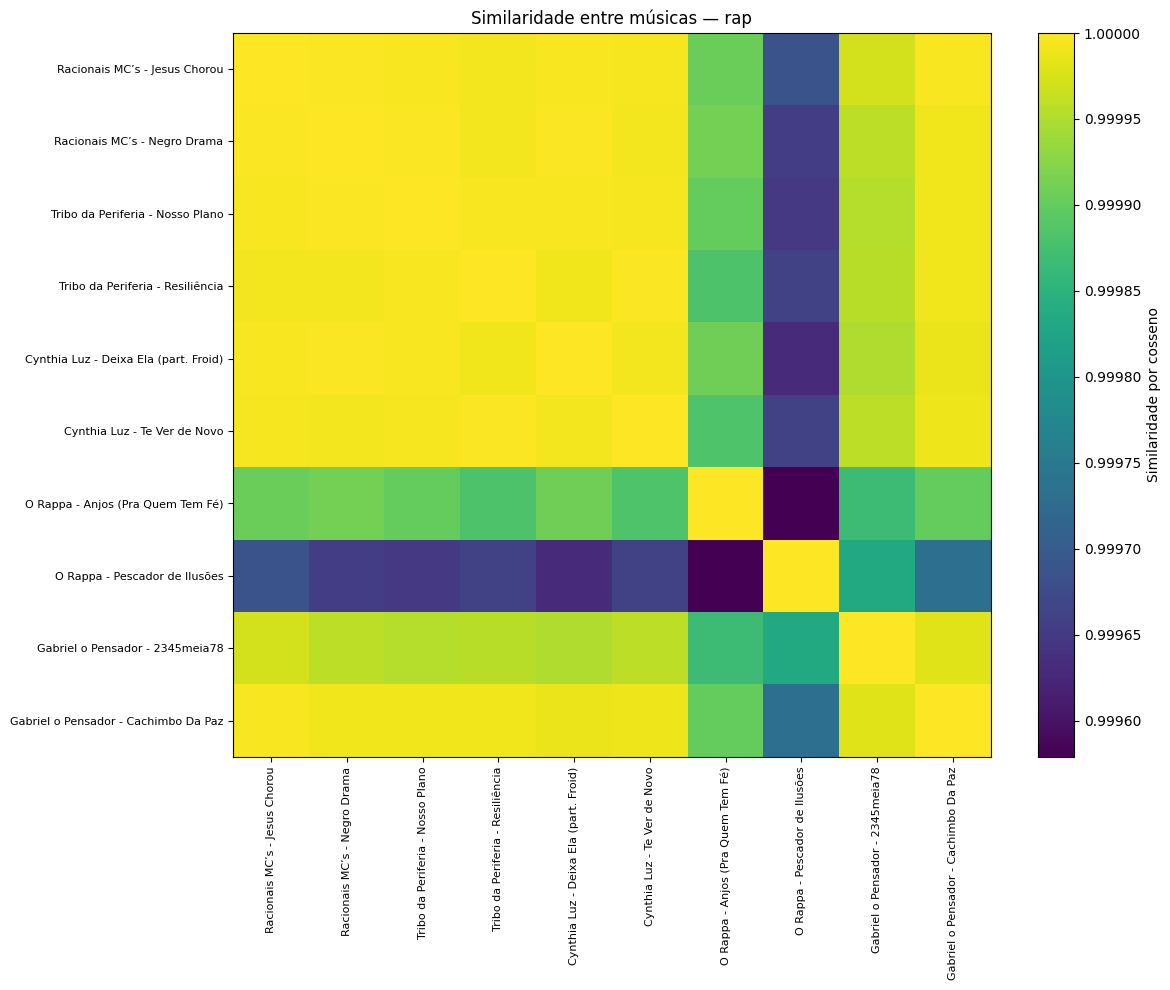

In [16]:
def plot_similarity_heatmap(indices, title="Heatmap de Similaridade"):
    subset_matrix = matriz_similaridade[np.ix_(indices, indices)]
    labels = [f"{df.loc[i, 'artist']} - {df.loc[i, 'song_title']}" for i in indices]

    plt.figure(figsize=(12, 10))
    plt.imshow(subset_matrix, aspect="auto")
    plt.colorbar(label="Similaridade por cosseno")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=90, fontsize=8)
    plt.yticks(range(len(labels)), labels, fontsize=8)
    plt.tight_layout()
    plt.show()

# Exemplo: até 10 músicas de um gênero específico
GENRE_TO_PLOT = "rap"
indices_genero = df[df["genre"] == GENRE_TO_PLOT].index[:10].tolist()
plot_similarity_heatmap(indices_genero, title=f"Similaridade entre músicas — {GENRE_TO_PLOT}")

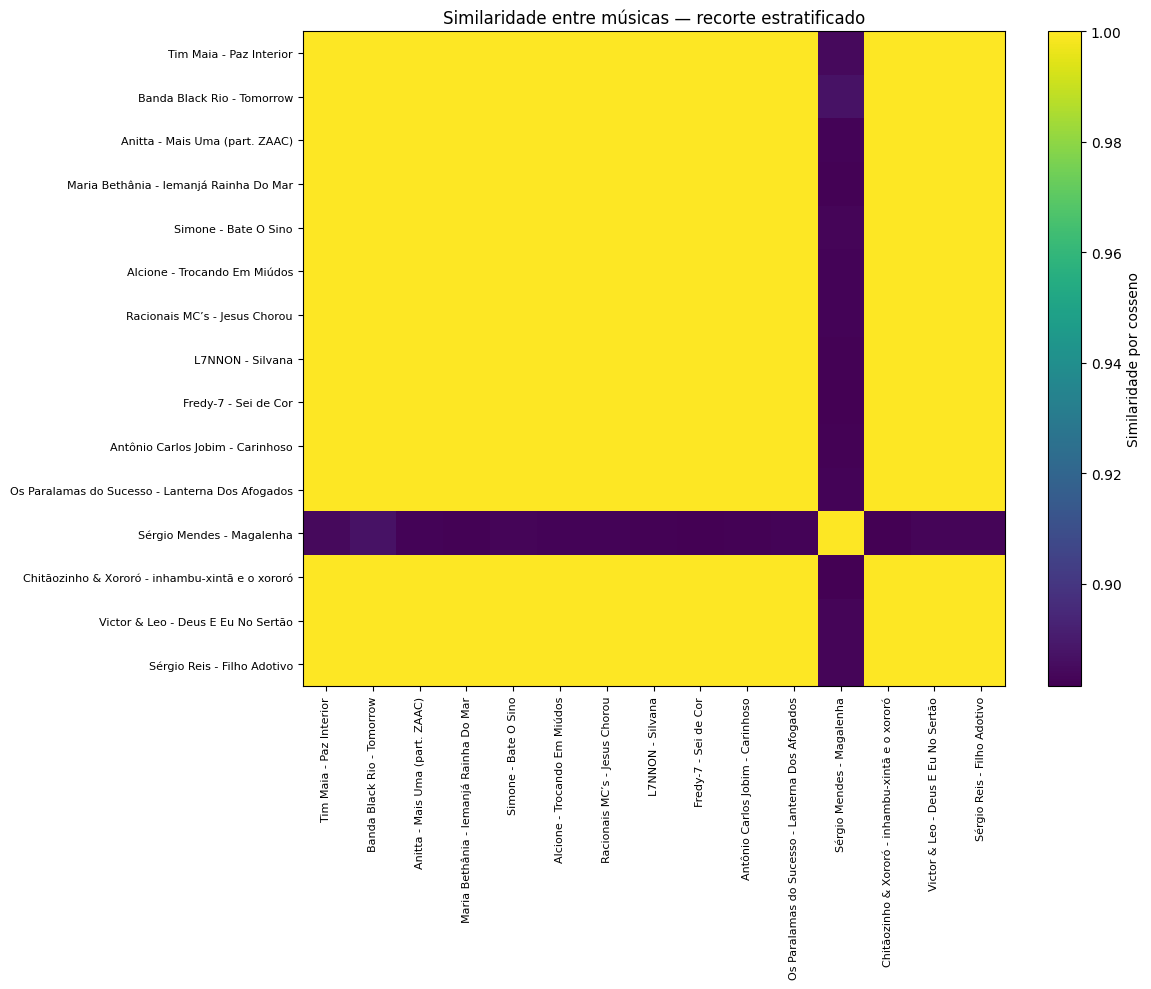

In [17]:
# Recorte estratificado: pega algumas músicas por gênero
sample_indices = (
    df.groupby("genre", group_keys=False)
      .apply(lambda x: x.sample(min(3, len(x)), random_state=42))
      .index
      .tolist()
)

plot_similarity_heatmap(sample_indices, title="Similaridade entre músicas — recorte estratificado")

## 12. PCA para visualização dos documentos

A matriz Word2Vec tem muitas dimensões. O PCA reduz os vetores para 2 ou 3 componentes, permitindo visualizar padrões gerais.

Importante: PCA é uma visualização aproximada; se os grupos aparecerem misturados, isso também é um resultado relevante.

Variância explicada pelo PCA 2D: [0.81411016 0.16384518]


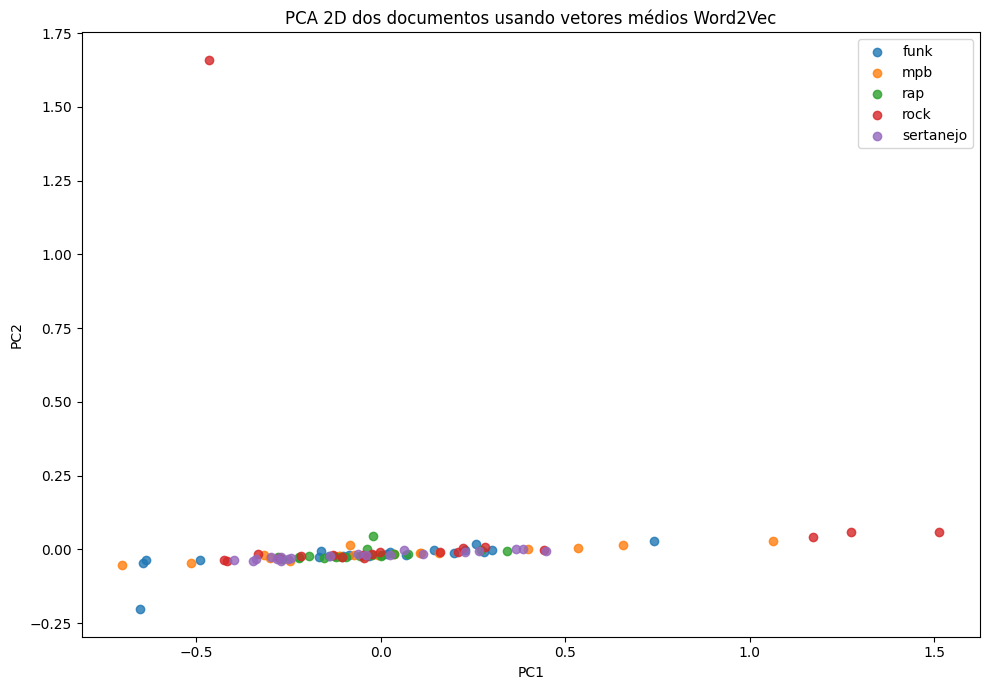

In [18]:
pca_2d = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(vetores_documentos)

pca_df = df[["genre", "artist", "song_title"]].copy()
pca_df["PC1"] = coords_2d[:, 0]
pca_df["PC2"] = coords_2d[:, 1]

print("Variância explicada pelo PCA 2D:", pca_2d.explained_variance_ratio_)

def plot_pca_2d(pca_df):
    plt.figure(figsize=(10, 7))

    for genre, group in pca_df.groupby("genre"):
        plt.scatter(group["PC1"], group["PC2"], label=genre, alpha=0.8)

    plt.title("PCA 2D dos documentos usando vetores médios Word2Vec")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pca_2d(pca_df)

In [19]:
# Versão interativa com Plotly
fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="genre",
    hover_data=["artist", "song_title"],
    title="PCA 2D interativo — Word2Vec por documento",
    width=900,
    height=650
)
fig.show()

## 13. KMeans sobre vetores Word2Vec dos documentos

Esta etapa é opcional. O KMeans tenta agrupar músicas a partir da similaridade dos vetores. Os clusters podem ou não coincidir com os gêneros musicais.

Isso é interessante para discutir se o agrupamento semântico das letras segue os gêneros ou se cruza temas entre gêneros diferentes.

In [20]:
NUM_CLUSTERS = 5

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
df["cluster_w2v"] = kmeans.fit_predict(vetores_documentos)
pca_df["cluster_w2v"] = df["cluster_w2v"].astype(str)

display(df[["genre", "artist", "song_title", "cluster_w2v"]].head())
print("Distribuição dos clusters:")
display(df["cluster_w2v"].value_counts().sort_index())

,genre,artist,song_title,cluster_w2v
0,mpb,Maria Bethânia,Iemanjá Rainha Do Mar,0
1,mpb,Maria Bethânia,Samba Da Bênção,0
2,mpb,Fagner,Borbulhas de Amor,1
3,mpb,Fagner,Oração de São Francisco,0
4,mpb,Marcos Valle,Um Novo Tempo,2


Distribuição dos clusters:


,count
cluster_w2v,
0,28
1,22
2,45
3,1
4,4


In [21]:
fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="cluster_w2v",
    symbol="genre",
    hover_data=["genre", "artist", "song_title"],
    title="Clusters KMeans sobre vetores Word2Vec visualizados com PCA",
    width=900,
    height=650
)
fig.show()

## 14. Exportação dos resultados

Salvamos uma versão do dataset com o cluster Word2Vec e as coordenadas PCA. Também salvamos os pares de músicas mais similares.

In [22]:
df_export = df.copy()
df_export["w2v_pc1"] = pca_df["PC1"]
df_export["w2v_pc2"] = pca_df["PC2"]

df_export.to_csv("songs_w2v_analysis.csv", index=False, encoding="utf-8")
top_pairs.to_csv("top_similar_song_pairs_w2v.csv", index=False, encoding="utf-8")

print("Arquivos salvos:")
print("- songs_w2v_analysis.csv")
print("- top_similar_song_pairs_w2v.csv")

Arquivos salvos:
- songs_w2v_analysis.csv
- top_similar_song_pairs_w2v.csv


## 15. Interpretação sugerida para o relatório

Pontos que você pode discutir:

1. **Qualidade do corpus:** letras de música têm repetições, interjeições e estruturas próprias, o que influencia o treinamento.
2. **Limitação do Word2Vec:** com apenas 100 músicas, o modelo aprende relações internas do corpus, não um conhecimento amplo da língua.
3. **Similaridade entre documentos:** músicas podem ser similares por tema, vocabulário ou estrutura repetitiva.
4. **PCA:** se os gêneros se misturam, isso pode indicar que a linguagem temática atravessa gêneros musicais.
5. **Clusters:** os agrupamentos podem revelar temas latentes, não necessariamente os gêneros originais.

Uma frase possível:

> A representação dos documentos por média de vetores Word2Vec permitiu medir similaridades semânticas entre letras de músicas. Embora o corpus seja pequeno, a abordagem fornece uma análise exploratória útil para identificar canções tematicamente próximas e visualizar padrões de agrupamento entre gêneros musicais.